In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers

%load_ext autoreload
%autoreload 2

from utils import scale_img

SEED = 143


I0000 00:00:1789315197.904934   35032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789315202.068200   35032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789315208.157767   35032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Loading Data

In [2]:
df_train = pd.read_csv('Dataset/train.csv')
df_test = pd.read_csv('Dataset/test.csv')

In [3]:
x = df_train.drop(['label'], axis=1).values
y = df_train['label'].values

In [4]:
x = x.reshape(-1, 28, 28, 1)
x_test = df_test.values.reshape(-1, 28, 28, 1)

In [5]:
x_train, x_cv, y_train, y_cv = train_test_split(x, y, test_size=0.2, random_state=SEED)

print(x_train.shape, y_train.shape)


(33600, 28, 28, 1) (33600,)


In [6]:
x_train_scaled, x_cv_scaled, x_test_scaled = scale_img(x_train, x_cv, x_test)

# Building the model

In [7]:
# model = tf.keras.Sequential([
#     layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28 ,1)),
    
#     layers.MaxPool2D(2,2),
    
#     layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    
#     layers.MaxPool2D(2,2),
    
#     layers.Flatten(),
    
#     layers.Dense(128, activation='relu'),
    
#     layers.Dense(10, activation='linear'),
# ])

model = tf.keras.models.load_model('models/pro1_accu_9896.keras')

E0000 00:00:1789315239.564128   35032 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789315239.769026   35371 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789315239.815077   35032 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
# model.compile(
#     optimizer = tf.keras.optimizers.Adam(0.001),
#     loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=['accuracy']
# )

# early_stopping = tf.keras.callbacks.EarlyStopping(  
#     monitor='val_loss',
#     patience=3,
# )

# history = model.fit(
#     x_train_scaled, y_train,
#     validation_data=(x_cv_scaled, y_cv),
#     callbacks=[early_stopping],
#     epochs=10
# )

In [9]:
pred_cv = model.predict(x_cv)
pred_cv = tf.nn.softmax(pred_cv)

W0000 00:00:1789315245.647026   35032 cpu_allocator_impl.cc:82] Allocation of 52684800 exceeds 10% of free system memory.


263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


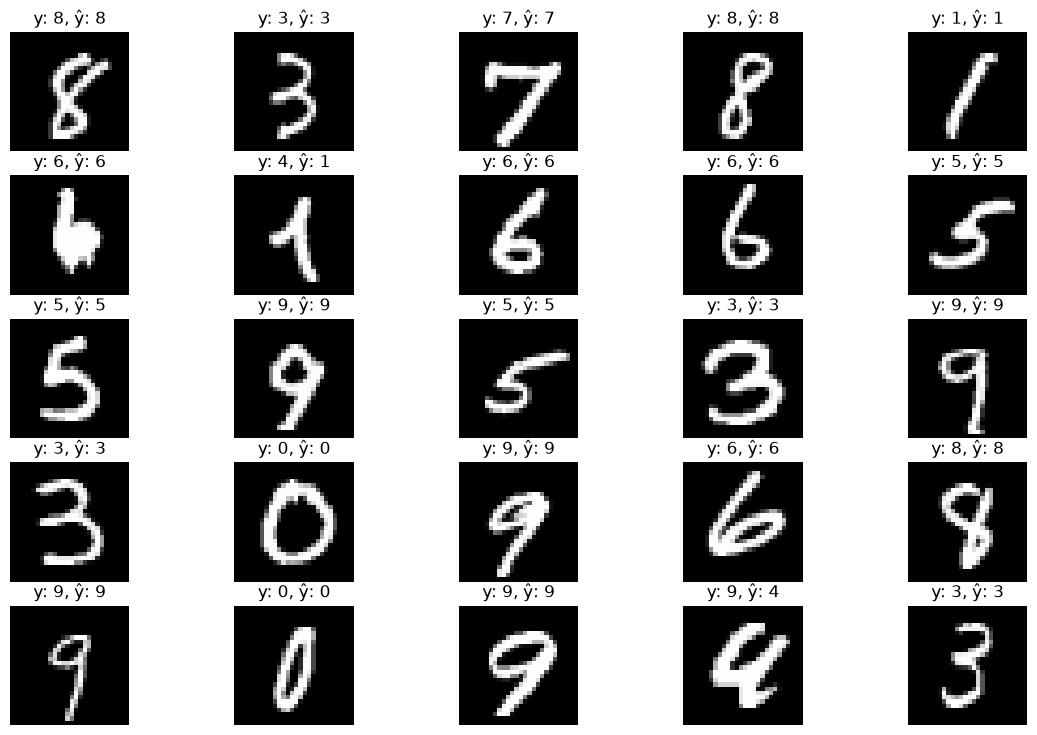

In [59]:
y_pred_result = np.argmax(pred_cv, axis=1)

fig, axes = plt.subplots(5, 5, figsize=(14, 9))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_cv[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"y: {y_cv[i]}, ŷ: {y_pred_result[i]}")
    ax.axis("off")

In [20]:
pred_test = model.predict(x_test_scaled)
pred_test = tf.nn.softmax(pred_test)

pred_test_label = np.argmax(pred_test, axis=1)
pred_test_label[:5]


W0000 00:00:1789315515.390986   35032 cpu_allocator_impl.cc:82] Allocation of 87808000 exceeds 10% of free system memory.


875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step


array([2, 0, 9, 9, 3])

In [55]:
df_final = pd.DataFrame({
    'ImageId' : range(1, x_test.shape[0] + 1),
    'Label' : pred_test_label.flatten()
})

In [57]:
df_final.to_csv('submission.csv', index=False)